In [2]:
# importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<p style="color:red">Task for this notebook</p>

- [ ] Move `_posts`, `_images` and `_comments` markdown information (see Step 1) into README.md (explain what each datasets does and what their features are)

In [9]:
# load dataset
D_westernu_posts = pd.read_csv("../data/reddit_data/WesternU_posts.csv")
D_westernu_images = pd.read_csv("../data/reddit_data/WesternU_images.csv")
D_westernu_comments = pd.read_csv("../data/reddit_data/WesternU_comments.csv")

NameError: name 'pd' is not defined

In [7]:
%%html
<style>
    table {align:left;display:block}
</style>

## Step 1 (Data Cleaning)
To make sense of our dataset (what is important and what is not), I have labelled them:

### _posts datasets
This datasets gets all the main posts made by a given user in a subreddit

| Column                         | Description                                      |
|--------------------------------|--------------------------------------------------|
| **subreddit**                  | Name of the current subreddit                    |
| **post_id**                    | Posts ID                                         |
| **post_title**                 | Title of post                                    |
| **post_score**                 | Posts net score (upvotes - downvotes)            |
| **post_url**                   | Direct reddit posts URL                          |
| **post_content_url**           | If image exists, links directly to post image    |
| **post_text**                  | Text contents of the post                        |
| **timestamp**                  | UTC timestamp                                    |
| **post_upvote_ratio**          | Upvote to downvote ratio                         |
| **post_ups**                   | Current post upvotes                             |
| **post_total_awards_received** | Post awards received                             |
| **post_link_flair_text**       | Post flairs (categories)                         |
| **post_author**                | Post author username                             |
| **post_num_comments**          | Post number of comments                          |
| **has_images**                 | Boolean if post have image or not                |
| **num_images**                 | Number of images the post contains (gallery)     |
| **is_gallery**                 | Boolean if gallery is exist                      |
| **content_type**               | Describes which format the content is            |


### _images datasets
This dataset gets the images made by any user in a subreddit (comments and posts)

| Column                         | Description                                             |
|--------------------------------|---------------------------------------------------------|
| **subreddit**                  | Name of the current subreddit                           |
| **post_id**                    | Posts ID                                                |
| **comment_id**                 | Comment_ID                                              |
| **image_index**                | Current index of the image (gallery style)              |
| **image_url**                  | Direct image URL                                        |
| **image_source**               | Indicates where image came from (comment, gallery, post |
| **image_type**                 | Indicates if its embedded, gallery or direct            |
| **media_id**                   | Media ID                                                |


### _comments datasets
This datasets gets all the comments from a parent post and their replies below it

| Column                         | Description                                      |
|--------------------------------|--------------------------------------------------|
| **post_id**                    | Posts ID                                         |
| **comment_id**                 ||
| **comment_text**               ||
| **comment_score**              ||
| **comment_author**             ||
| **comment_created_utc**        ||
| **parent_id**                  ||
| **reply_to_id**                ||
| **comment_sentiment**          ||
| **has_images**                 ||
| **num_images**                 ||
| **image_urls**                 ||
| **subreddit**                  ||


In [144]:
# note to self, might wanna delete post_content_url as it serves not much of a purpose, only creates dupplicate
# links for non image posts and gallery links diretly to the post itself

In [121]:
print(D_westernu_posts.isna().sum()) # show missing values
display(D_westernu_posts.head())

subreddit                      0
post_id                        0
post_title                     0
post_score                     0
post_url                       0
post_content_url               0
post_text                      8
timestamp                      0
post_upvote_ratio              0
post_ups                       0
post_total_awards_received     0
post_link_flair_text          51
post_author                    0
post_num_comments              0
has_images                     0
num_images                     0
is_gallery                     0
content_type                   0
dtype: int64


,subreddit,post_id,post_title,post_score,post_url,post_content_url,post_text,timestamp,post_upvote_ratio,post_ups,post_total_awards_received,post_link_flair_text,post_author,post_num_comments,has_images,num_images,is_gallery,content_type
0,WesternU,12p2lmp,Anyone looking for a roomie at western????,2,https://reddit.com/r/WesternU/comments/12p2lmp...,https://www.reddit.com/r/WesternU/comments/12p...,\nI’m doing med sci or health sci as an undergrad,1.681707e+09,1.0,2,0,NaN,Specific-Check7872,2,False,0,False,text
1,WesternU,12fi6k7,better pre med route 🤔,2,https://reddit.com/r/WesternU/comments/12fi6k7...,https://www.reddit.com/r/WesternU/comments/12f...,Rethinking my life choices atm\n\n[View Poll](...,1.680951e+09,1.0,2,0,NaN,Purple_Character6184,0,False,0,False,text
2,WesternU,12dvo59,western vs. usask mph?,3,https://reddit.com/r/WesternU/comments/12dvo59...,https://www.reddit.com/r/WesternU/comments/12d...,i got accepted into both usask and western mas...,1.680810e+09,1.0,3,0,NaN,OwnButterscotch4039,1,False,0,False,text
3,WesternU,12bmcep,transfer to western,1,https://reddit.com/r/WesternU/comments/12bmcep...,https://www.reddit.com/r/WesternU/comments/12b...,Interested in transferring to western engineer...,1.680622e+09,1.0,1,0,NaN,Far-Ask-9746,0,False,0,False,text
4,WesternU,11mj5tr,Do Western admissions officers care if I took ...,1,https://reddit.com/r/WesternU/comments/11mj5tr...,https://www.reddit.com/r/WesternU/comments/11m...,"Hello,\nI’m a mature student that didn’t do to...",1.678338e+09,1.0,1,0,NaN,Melodic_Rabbit7187,0,False,0,False,text


In [123]:
print(D_westernu_images.isna().sum()) # show missing values
display(D_westernu_images.head())

subreddit       0
post_id         0
image_index     0
image_url       0
image_source    0
image_type      0
media_id        1
dtype: int64


,subreddit,post_id,image_index,image_url,image_source,image_type,media_id
0,WesternU,zeig23,0,https://preview.redd.it/1in29fq6hc4a1.png?widt...,post_text,embedded_link,NaN


In [125]:
print(D_westernu_comments.isna().sum()) # show missing values
display(D_westernu_comments.head())

post_id                 0
comment_id              0
comment_text            0
comment_score           0
comment_author          0
comment_created_utc     0
parent_id               0
reply_to_id             0
comment_sentiment      47
has_images              0
num_images              0
image_urls             47
subreddit               0
dtype: int64


,post_id,comment_id,comment_text,comment_score,comment_author,comment_created_utc,parent_id,reply_to_id,comment_sentiment,has_images,num_images,image_urls,subreddit
0,12p2lmp,kvayuwc,Meee I’m probably doing health sci,1,[deleted],1.710695e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
1,12p2lmp,jlprjaz,Hi,1,Purple_Character6184,1.685117e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
2,12dvo59,lm2j9yu,"Congrats! May I know your stats, like gpa and ...",1,Only_Researcher6011,1.725773e+09,t3_12dvo59,12dvo59,NaN,False,0,NaN,WesternU
3,ztfu7e,lm9oi3b,I am interested in!,1,Only_Researcher6011,1.725886e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU
4,ztfu7e,m7hxd3l,yes,1,Eastern-State6466,1.737054e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU


### Discussion
Evidently, we see we have missing values in our dataset and comment_sentiment hasn't been labelled yet. As stated in our Phase II document, we will label them using VADER (Valence Aware Dictionary and sEntiment Reasoner) which is effective for social media text.

In [57]:
# Testing to see if it works

nltk.download("vader_lexicon")
import nltk
        
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
text = D_westernu_comments["comment_text"][0]
scores = analyzer.polarity_scores(text)

print(scores)
print(text)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Meee I’m probably doing health sci


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\322jl\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [112]:
D_westernu_comments["sentiment_scores"] = D_westernu_comments["comment_text"].apply(lambda x: analyzer.polarity_scores(x))
D_westernu_comments["compound"] = D_westernu_comments["sentiment_scores"].apply(lambda x: x["compound"])

In [114]:
def get_sentiment_label(compound_score):
    if compound_score >= 0.05: return "positive"
    elif compound_score <= -0.05: return "negative"
    else: return "neutral"
        
D_westernu_comments["comment_sentiment"] = D_westernu_comments["compound"].apply(get_sentiment_label)

In [116]:
pd.set_option("display.max_colwidth", None) # removes truncated text from table
display(D_westernu_comments[["comment_text","comment_sentiment","sentiment_scores","compound"]].head())
pd.set_option("display.max_colwidth", 50) # goes back to normal

,comment_text,comment_sentiment,sentiment_scores,compound
0,Meee I’m probably doing health sci,neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}",0.0000
1,Hi,neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}",0.0000
2,"Congrats! May I know your stats, like gpa and lab experience?",positive,"{'neg': 0.0, 'neu': 0.564, 'pos': 0.436, 'compound': 0.7345}",0.7345
3,I am interested in!,positive,"{'neg': 0.0, 'neu': 0.401, 'pos': 0.599, 'compound': 0.4574}",0.4574
4,yes,positive,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.4019}",0.4019


## Step 2 (Data Explatory)

..
I feel its best to completely remove the null values since we have alot of datasets and imputing wouldn't make sense as we have unique ID's and since we're dealing with a human text sentimental analysis it would be in our best interest to keep the sementic meanings intact as much as possible and as early on.

In [103]:
#D_westernu_posts_clean = D_westernu_posts.dropna()
#D_westernu_images_clean = D_westernu_images.dropna()
#D_westernu_comments_clean = D_westernu_comments.dropna()

In [101]:
#display(D_westernu_posts_clean.head())
#display(D_westernu_images_clean.head())
#display(D_westernu_comments_clean.head())

C:\Users\322jl\AppData\Local\Temp\ipykernel_6384\1526107583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="comment_sentiment", data=D_westernu_comments, palette={"positive": "green", "negative": "red", "neutral": "gray"})


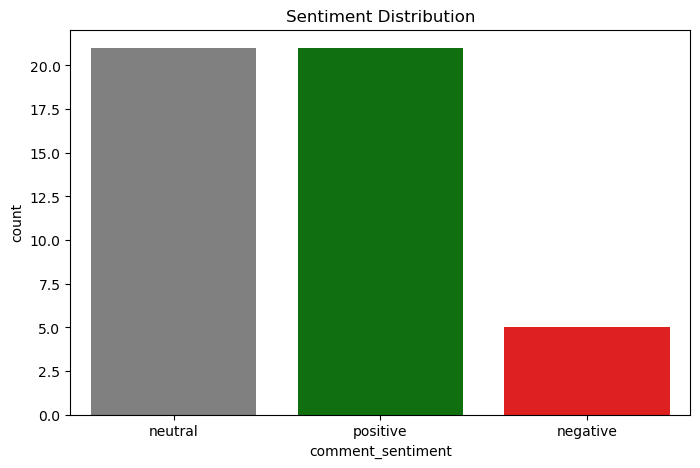

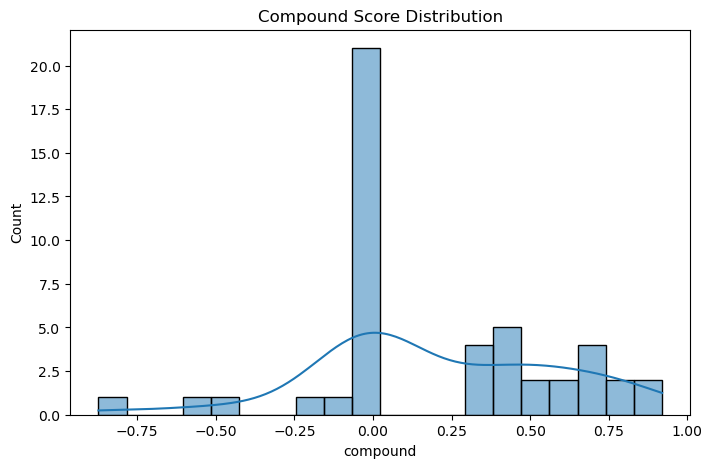

In [126]:
# EDA
plt.figure(figsize=(8, 5))
sns.countplot(x="comment_sentiment", data=D_westernu_comments, palette={"positive": "green", "negative": "red", "neutral": "gray"})
plt.title("Sentiment Distribution")
plt.show()

# Plotting compound score distribution
plt.figure(figsize=(8, 5))
sns.histplot(D_westernu_comments["compound"], bins=20, kde=True)
plt.title("Compound Score Distribution")
plt.show()

## Step 2 (XX)
Text